In [1]:
import fitz
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [2]:
# ── CELL 2: CONFIG + SEP DATE CALENDAR ──────────────────────────────
import os
import requests
from datetime import date

# SEP MEETING DATES — update this list when Fed publishes beyond 2027
SEP_DATES = [
    # 2025
    date(2025, 3, 19), date(2025, 6, 18),
    date(2025, 9, 17), date(2025, 12, 10),
    # 2026
    date(2026, 3, 18), date(2026, 6, 17),
    date(2026, 9, 16), date(2026, 12,  9),
    # 2027  ← add 2028 dates here once Fed publishes them
    date(2027, 3, 17), date(2027, 6, 16),
    date(2027, 9, 15), date(2027, 12,  8),
]

# GRAPH CROP 
top    = 410
bottom = 1750
left   = 320
right  = 2200

In [3]:
# ── CELL 3: SEP DOWNLOADER ───────────────────────────────────────────
BASE_URL = "https://www.federalreserve.gov/monetarypolicy/files/"
SAVE_DIR = "sep_pdfs"
os.makedirs(SAVE_DIR, exist_ok=True)

def build_sep_url(sep_date):
    return BASE_URL + f"fomcprojtabl{sep_date.strftime('%Y%m%d')}.pdf"

def download_sep(sep_date):
    local_path = os.path.join(SAVE_DIR, f"SEP_{sep_date}.pdf")
    if os.path.exists(local_path):
        print(f"[CACHE]  {local_path}")
        return local_path
    url = build_sep_url(sep_date)
    print(f"[FETCH]  {url}")
    r = requests.get(url, timeout=30)
    if r.status_code == 200:
        with open(local_path, "wb") as f:
            f.write(r.content)
        print(f"[OK]     Saved → {local_path}")
        return local_path
    elif r.status_code == 404:
        print(f"[SKIP]   Not published yet: {sep_date}")
        return None
    else:
        print(f"[ERROR]  HTTP {r.status_code}")
        return None

# ── PICK YOUR DATE HERE ──────────────────────────────────────────────
latest_date = date(2026, 6, 17)   # ← only thing you change each run

pdf_path      = download_sep(latest_date)
starting_year = latest_date.year

# Auto-detect clusters based on month
if latest_date.month in (9, 12):  # September and December = 5 clusters
    n_clusters = 5
else:                              # March and June = 4 clusters
    n_clusters = 4

print(f"\nLoaded SEP: {latest_date}  →  {pdf_path}")
print(f"n_clusters set to: {n_clusters}")

[CACHE]  sep_pdfs/SEP_2026-06-17.pdf

Loaded SEP: 2026-06-17  →  sep_pdfs/SEP_2026-06-17.pdf
n_clusters set to: 4


In [4]:
def detect_dots(mask):

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    )

    centers = []

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]

        if area > 20:

            cx, cy = centroids[i]

            centers.append((cx, cy))

    return centers

In [5]:
pdf_path = pdf_path
doc = fitz.open(pdf_path)

print("Pages:", len(doc))

Pages: 17


In [6]:
page = doc[3]

In [7]:
pix = page.get_pixmap(matrix=fitz.Matrix(4,4))

pix.save("page.png")

In [8]:
img = cv2.imread("page.png")

In [10]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [12]:
crop = img[top:bottom, left:right]

In [13]:
crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

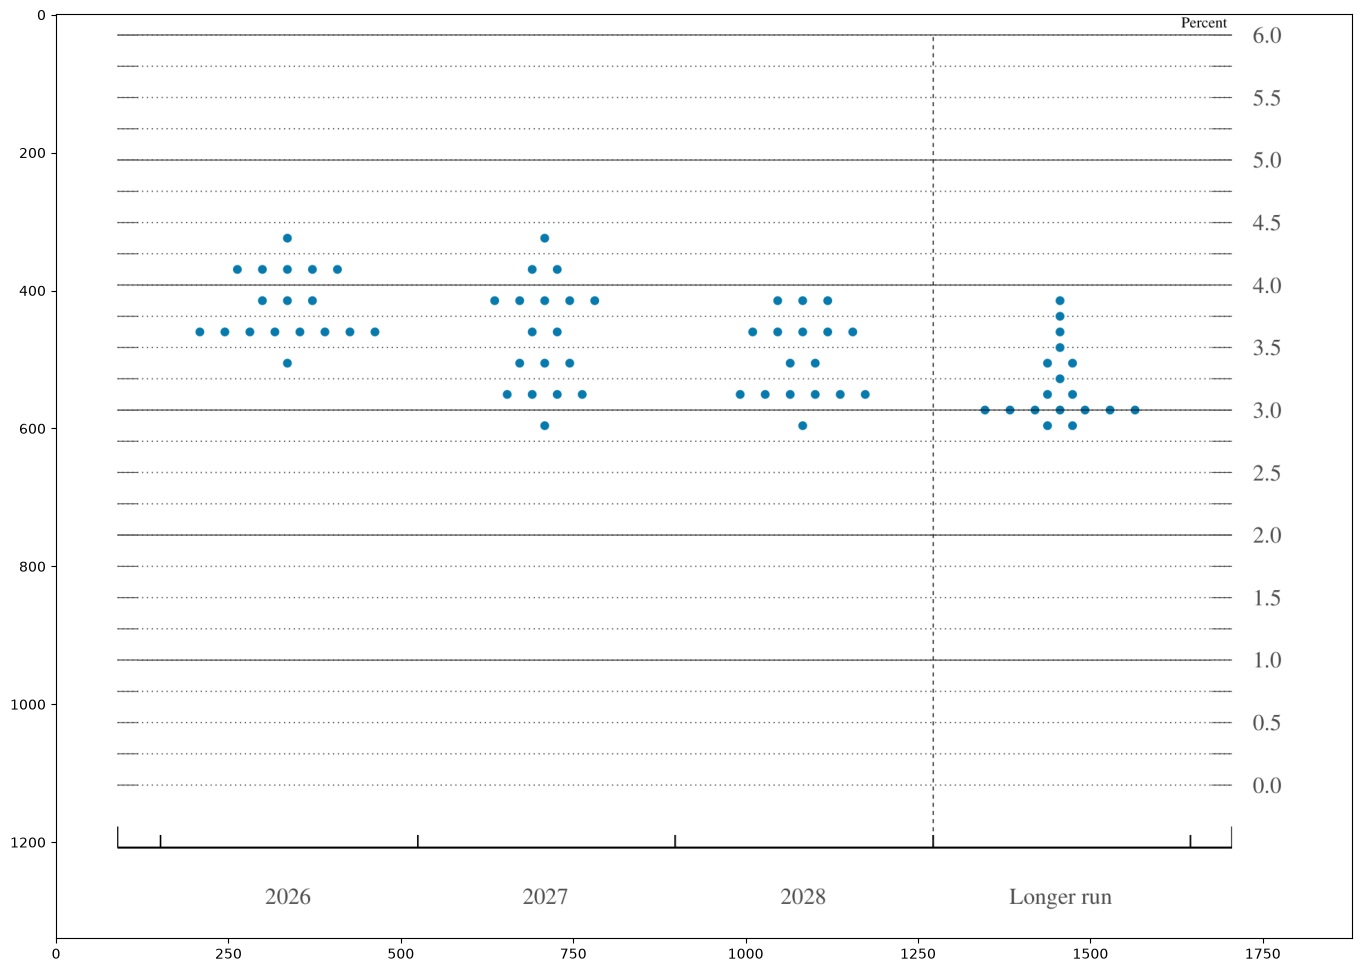

In [14]:
plt.figure(figsize=(18,12))
plt.imshow(crop_rgb)
plt.axis("on")
plt.show()

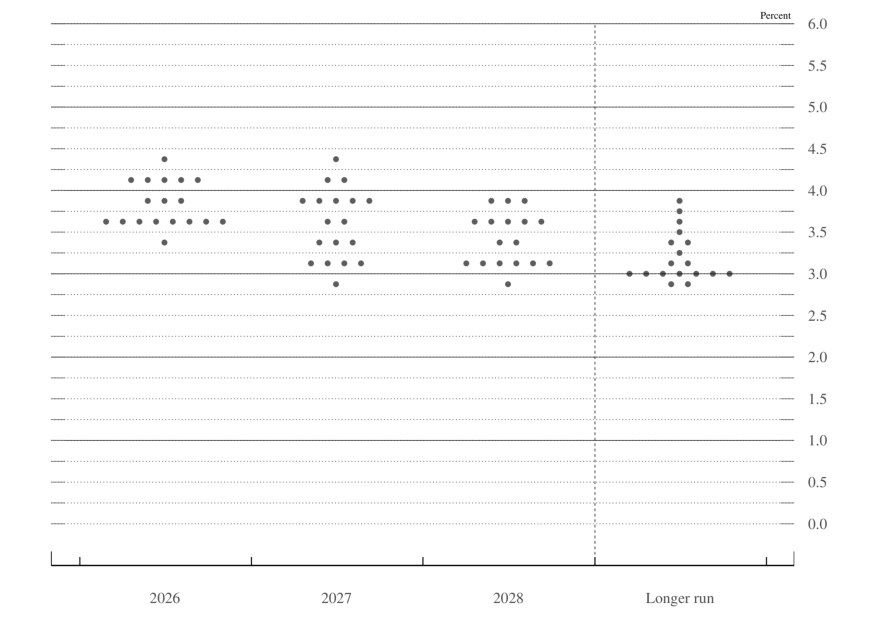

In [15]:
gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(14,8))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

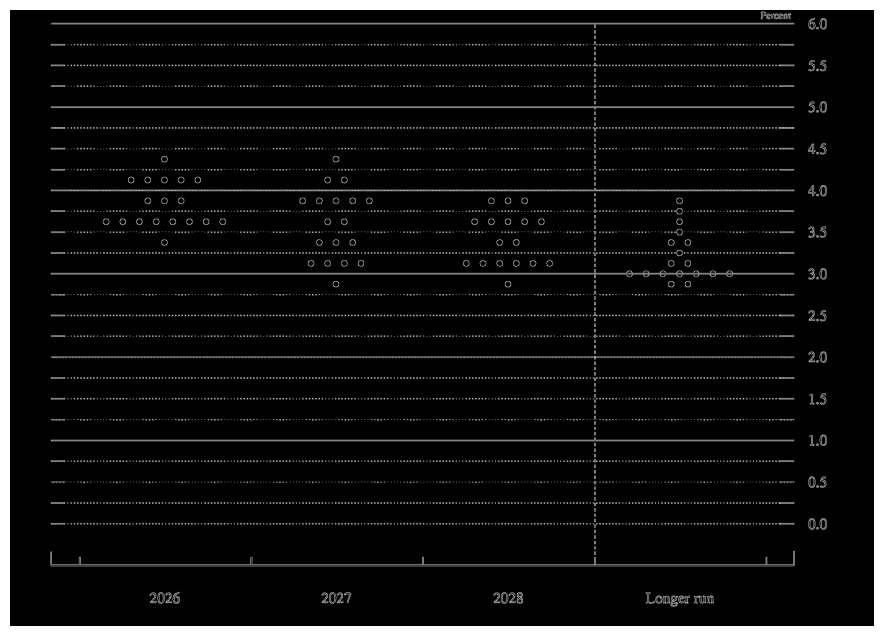

In [16]:
edges = cv2.Canny(
    gray,
    50,
    150
)

plt.figure(figsize=(14,8))
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

In [17]:
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=1000,
    maxLineGap=20
)

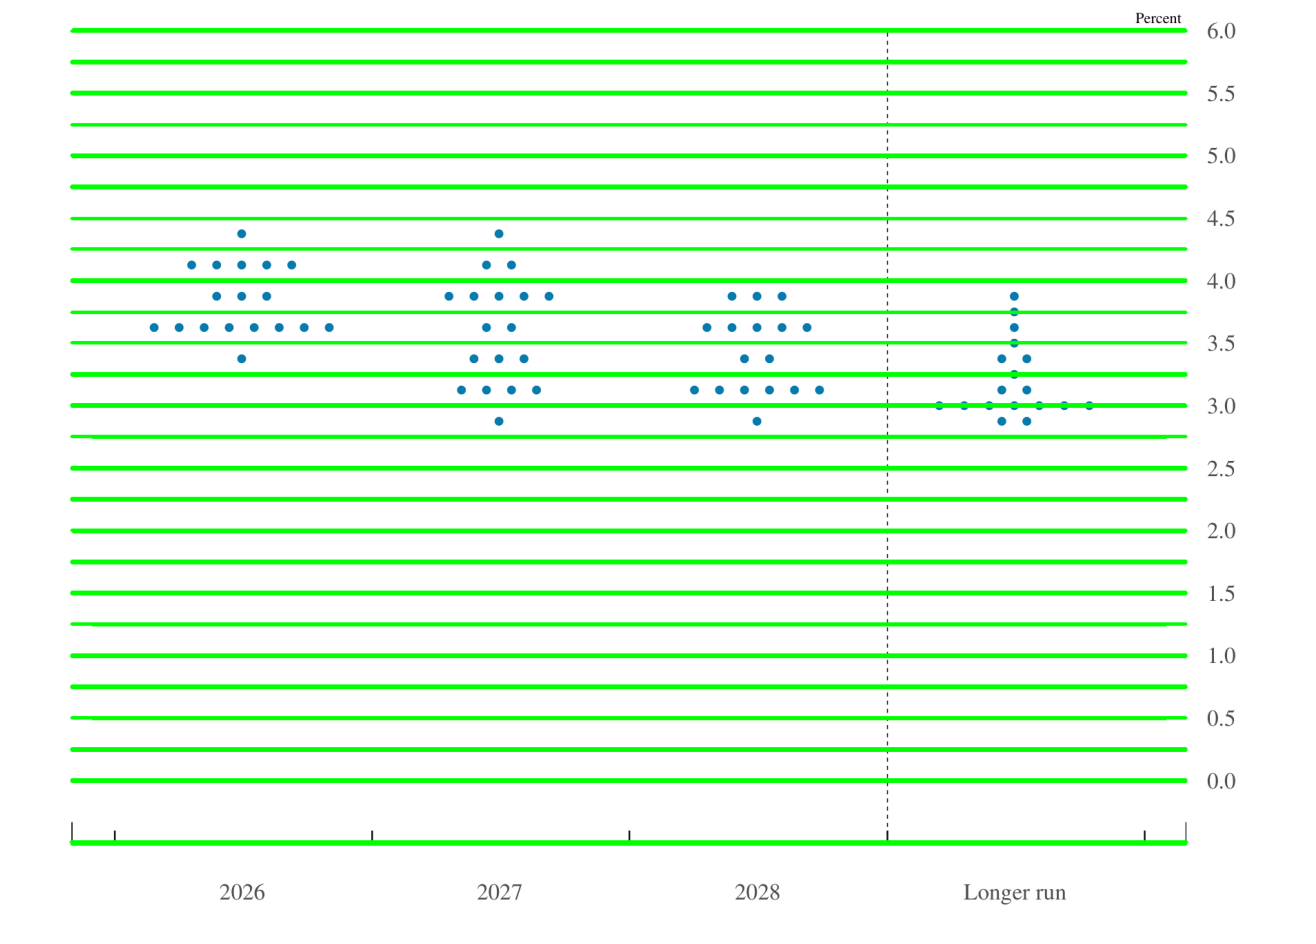

In [18]:
line_img = crop.copy()

if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line[0]

        if abs(y2 - y1) < 5:

            cv2.line(
                line_img,
                (x1, y1),
                (x2, y2),
                (0,255,0),
                3
            )

line_rgb = cv2.cvtColor(
    line_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(18,12))
plt.imshow(line_rgb)
plt.axis("off")
plt.show()

In [19]:
y_lines = []

if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line[0]

        if abs(y2 - y1) < 5:

            y_lines.append(y1)

print(y_lines[:50])

[np.int32(210), np.int32(1209), np.int32(937), np.int32(30), np.int32(212), np.int32(1206), np.int32(393), np.int32(391), np.int32(935), np.int32(28), np.int32(574), np.int32(572), np.int32(754), np.int32(756), np.int32(121), np.int32(1073), np.int32(529), np.int32(482), np.int32(119), np.int32(665), np.int32(844), np.int32(438), np.int32(663), np.int32(846), np.int32(255), np.int32(257), np.int32(799), np.int32(527), np.int32(1071), np.int32(74), np.int32(801), np.int32(1118), np.int32(166), np.int32(1116), np.int32(980), np.int32(982), np.int32(346), np.int32(1026), np.int32(890), np.int32(708), np.int32(710), np.int32(256), np.int32(528), np.int32(302), np.int32(664), np.int32(76), np.int32(618), np.int32(1117), np.int32(1072), np.int32(800)]


In [20]:
unique_y = []

for y in sorted(y_lines):

    if not unique_y:

        unique_y.append(y)

    elif abs(y - unique_y[-1]) > 10:

        unique_y.append(y)

print(unique_y)

[np.int32(28), np.int32(74), np.int32(119), np.int32(166), np.int32(210), np.int32(255), np.int32(302), np.int32(346), np.int32(391), np.int32(438), np.int32(482), np.int32(527), np.int32(572), np.int32(618), np.int32(663), np.int32(708), np.int32(754), np.int32(799), np.int32(844), np.int32(890), np.int32(935), np.int32(980), np.int32(1026), np.int32(1071), np.int32(1116), np.int32(1206)]


In [21]:
# Auto-calibrate from detected grid lines
gaps = [unique_y[i+1] - unique_y[i] for i in range(len(unique_y)-1)]
median_gap = np.median(gaps)

# Find the first line that has a normal gap to the next one
top_grid_y = None
for i in range(len(unique_y) - 1):
    if abs((unique_y[i+1] - unique_y[i]) - median_gap) < 10:
        top_grid_y = unique_y[i]
        break

pixels_per_0125 = median_gap / 2  # 53/2 = 26.5 pixels per 0.125%
top_grid_value = 6.0

print(f"pixels_per_0125: {pixels_per_0125}")
print(f"top_grid_y: {top_grid_y}")
print(f"top_grid_value: {top_grid_value}")

pixels_per_0125: 22.5
top_grid_y: 28
top_grid_value: 6.0


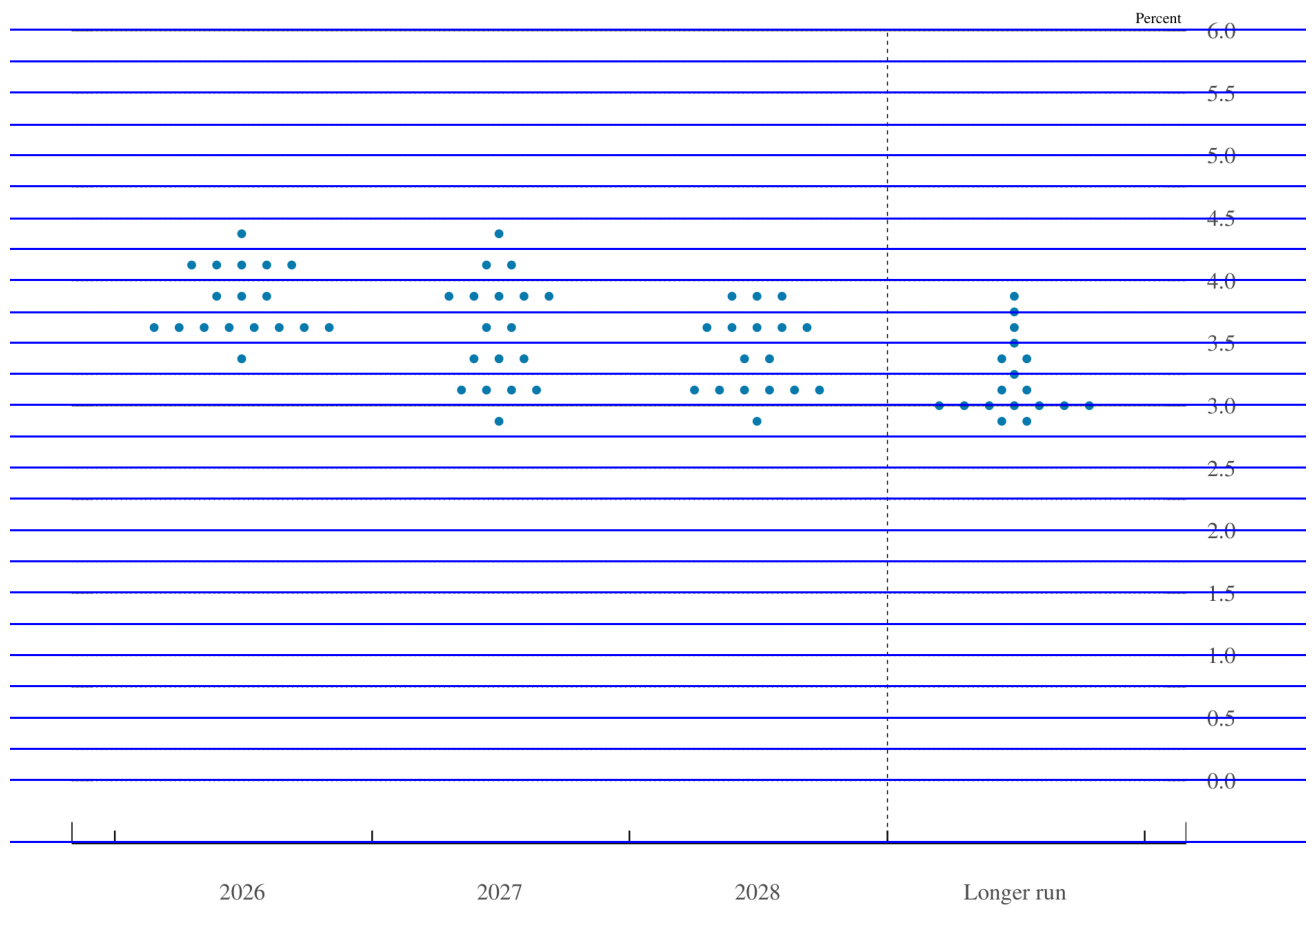

In [22]:
line_view = crop.copy()

for y in unique_y:

    cv2.line(
        line_view,
        (0, int(y)),
        (line_view.shape[1], int(y)),
        (255,0,0),
        2
    )

line_view_rgb = cv2.cvtColor(
    line_view,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(18,12))
plt.imshow(line_view_rgb)
plt.axis("off")
plt.show()

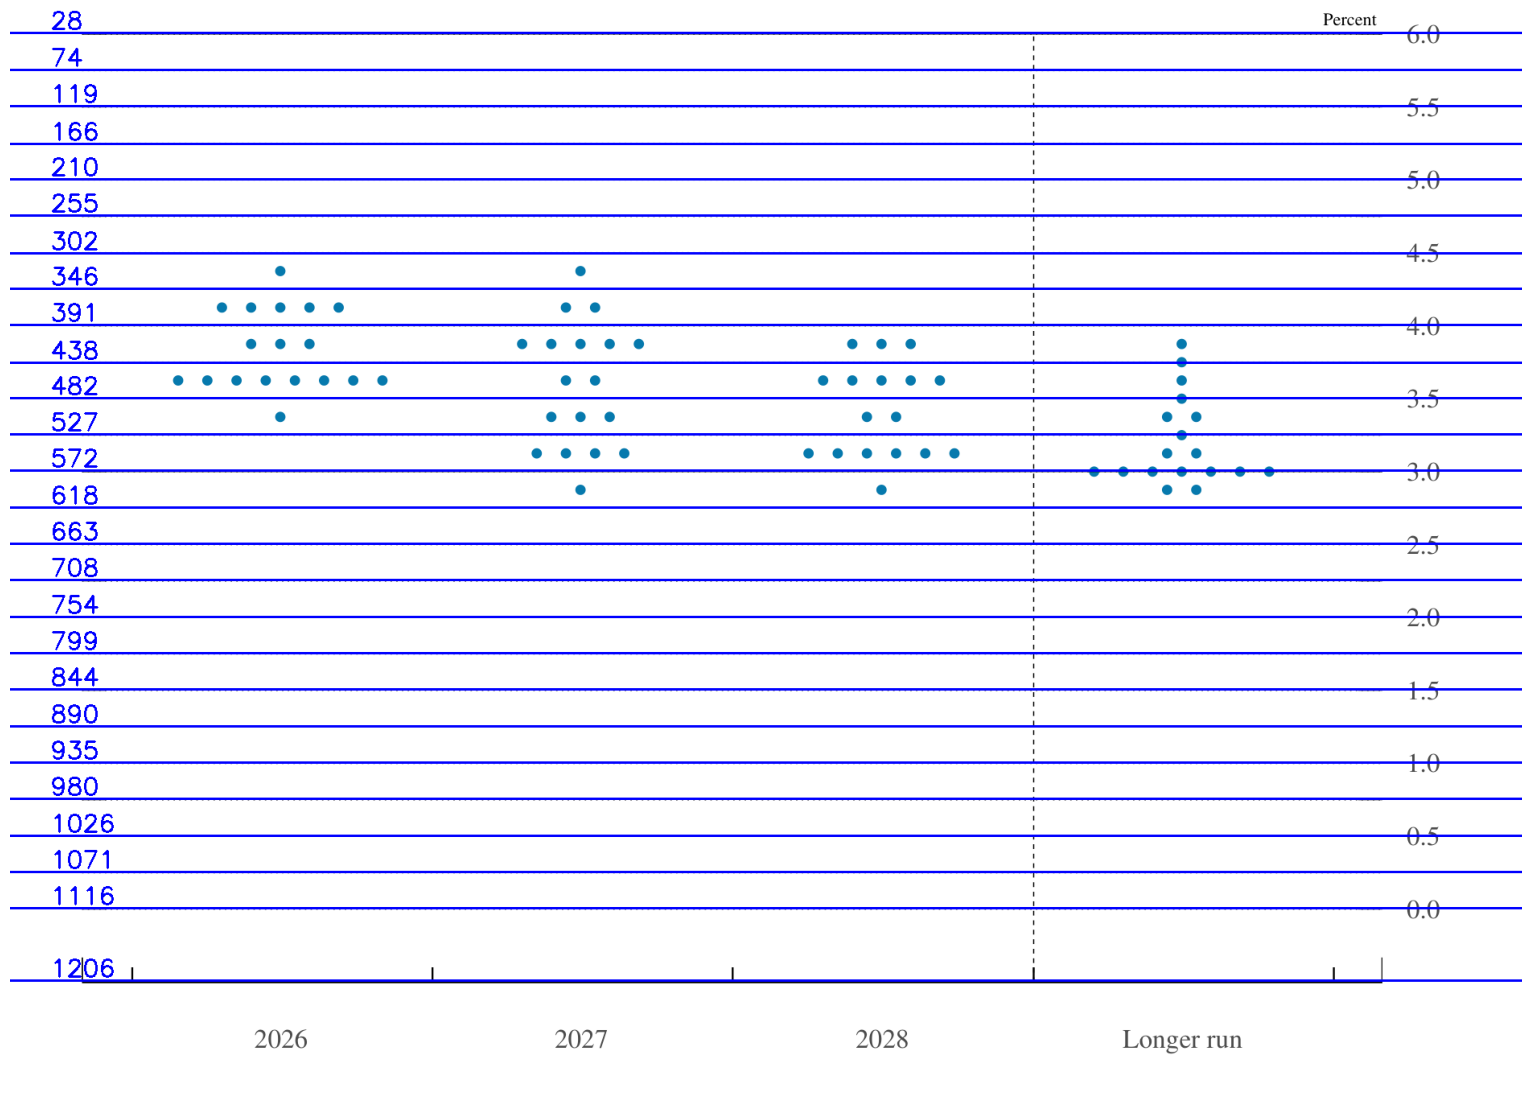

In [23]:
line_labels = crop.copy()

for y in unique_y:

    cv2.line(
        line_labels,
        (0, int(y)),
        (line_labels.shape[1], int(y)),
        (255,0,0),
        2
    )

    cv2.putText(
        line_labels,
        str(int(y)),
        (50, int(y)-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255,0,0),
        2
    )

line_labels_rgb = cv2.cvtColor(
    line_labels,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(20,14))
plt.imshow(line_labels_rgb)
plt.axis("off")
plt.show()

In [24]:
hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)

In [25]:
lower_blue = np.array([80, 50, 50])
upper_blue = np.array([130, 255, 255])

mask = cv2.inRange(hsv, lower_blue, upper_blue)

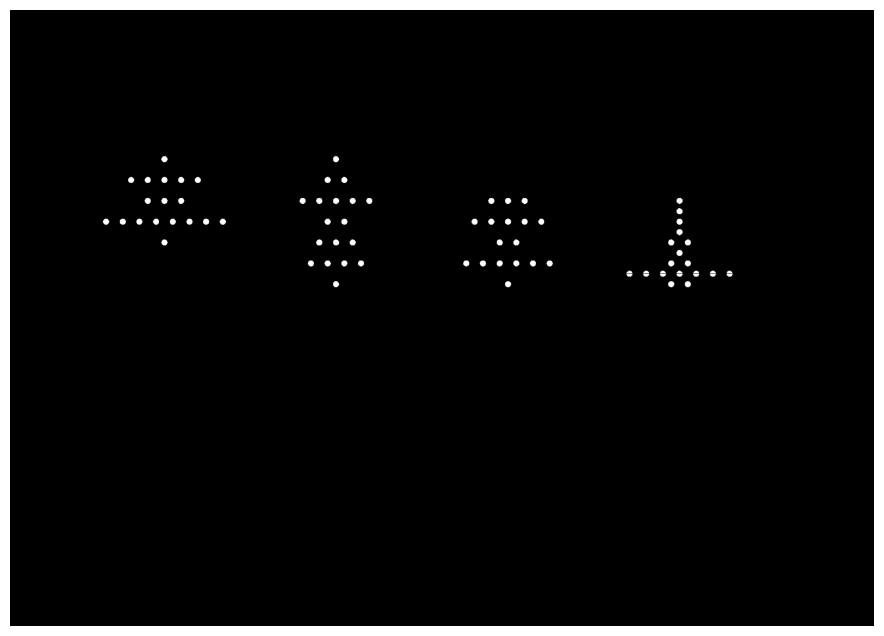

In [26]:
plt.figure(figsize=(14,8))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [27]:
kernel = np.ones((3,3), np.uint8)

mask_clean = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)

mask_clean = cv2.morphologyEx(
    mask_clean,
    cv2.MORPH_CLOSE,
    kernel
)

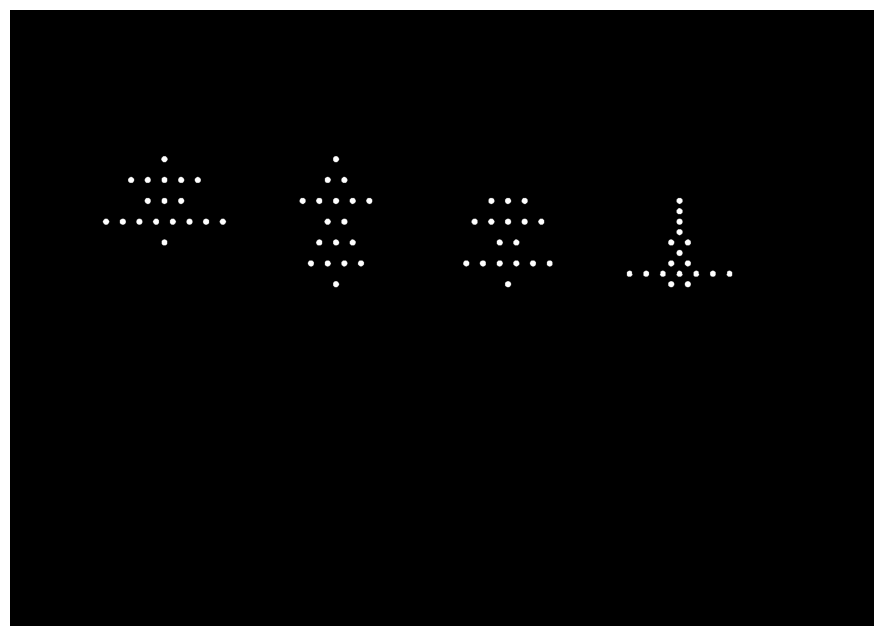

In [28]:
plt.figure(figsize=(14,8))
plt.imshow(mask_clean, cmap="gray")
plt.axis("off")
plt.show()

In [29]:
centers = detect_dots(mask_clean)

In [30]:
print(centers[:10])

[(np.float64(335.5), np.float64(324.0)), (np.float64(708.6444444444444), np.float64(324.0)), (np.float64(262.95522388059703), np.float64(369.3358208955224)), (np.float64(299.16911764705884), np.float64(369.2352941176471)), (np.float64(335.5), np.float64(369.1666666666667)), (np.float64(371.83088235294116), np.float64(369.2352941176471)), (np.float64(408.04477611940297), np.float64(369.3358208955224)), (np.float64(690.6444444444444), np.float64(369.162962962963)), (np.float64(726.8592592592593), np.float64(369.27407407407406)), (np.float64(299.16911764705884), np.float64(414.7647058823529))]


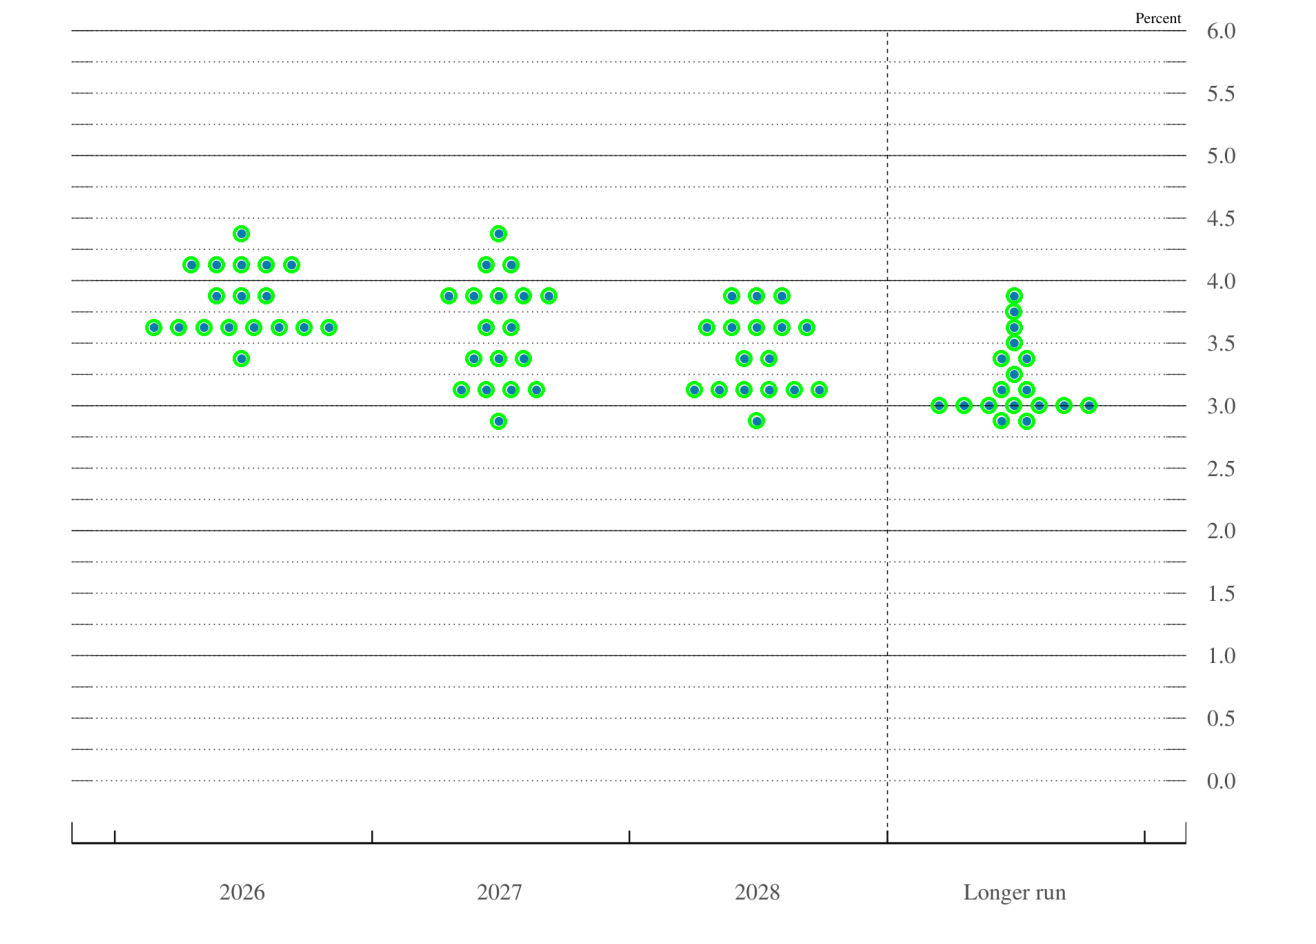

In [31]:
test = crop.copy()

for cx, cy in centers:

    cv2.circle(
        test,
        (int(cx), int(cy)),
        10,
        (0,255,0),
        3
    )

test_rgb = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18,12))
plt.imshow(test_rgb)
plt.axis("off")
plt.show()

In [32]:
x_values = np.array(
    [d[0] for d in centers]
).reshape(-1,1)

In [33]:
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=0,
    n_init=10
)

kmeans.fit(x_values)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",0
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 1)","[[1455

In [34]:
x_cluster_centers = list(sorted(
    kmeans.cluster_centers_.flatten()
))
print(centers)

[(np.float64(335.5), np.float64(324.0)), (np.float64(708.6444444444444), np.float64(324.0)), (np.float64(262.95522388059703), np.float64(369.3358208955224)), (np.float64(299.16911764705884), np.float64(369.2352941176471)), (np.float64(335.5), np.float64(369.1666666666667)), (np.float64(371.83088235294116), np.float64(369.2352941176471)), (np.float64(408.04477611940297), np.float64(369.3358208955224)), (np.float64(690.6444444444444), np.float64(369.162962962963)), (np.float64(726.8592592592593), np.float64(369.27407407407406)), (np.float64(299.16911764705884), np.float64(414.7647058823529)), (np.float64(335.5), np.float64(414.8333333333333)), (np.float64(371.83088235294116), np.float64(414.7647058823529)), (np.float64(636.0955882352941), np.float64(414.74264705882354)), (np.float64(672.2463768115942), np.float64(414.7536231884058)), (np.float64(708.7647058823529), np.float64(414.83088235294116)), (np.float64(744.9407407407407), np.float64(414.7111111111111)), (np.float64(781.16911764705

In [36]:
def y_to_rate(y):

    steps = (
        (y - top_grid_y)
        / pixels_per_0125
    )

    rate = (
        top_grid_value
        - (steps * 0.125)
    )

    rounded = (
        round(rate / 0.125)
        * 0.125
    )

    return rounded

In [37]:
print("sample dot positions (first 10):")
for cx, cy in centers[:10]:
    print(f"  cx={cx:.0f}, cy={cy:.0f} → rate={y_to_rate(cy)}")

sample dot positions (first 10):
  cx=336, cy=324 → rate=4.375
  cx=709, cy=324 → rate=4.375
  cx=263, cy=369 → rate=4.125
  cx=299, cy=369 → rate=4.125
  cx=336, cy=369 → rate=4.125
  cx=372, cy=369 → rate=4.125
  cx=408, cy=369 → rate=4.125
  cx=691, cy=369 → rate=4.125
  cx=727, cy=369 → rate=4.125
  cx=299, cy=415 → rate=3.875


In [38]:
rows = []

for cx, cy in centers:

    nearest = min(
        x_cluster_centers,
        key=lambda c: abs(cx - c)
    )

    cluster_index = (
        x_cluster_centers.index(nearest)
    )

    if cluster_index < n_clusters - 1:

        year = str(
            starting_year
            + cluster_index
        )

    else:

        year = "Longer Run"

    rows.append({
        "Year": year,
        "Projection": y_to_rate(cy)
    })

df = pd.DataFrame(rows)

In [39]:
print(df.sort_values(["Year", "Projection"]))

          Year  Projection
39        2026       3.375
22        2026       3.625
23        2026       3.625
24        2026       3.625
25        2026       3.625
..         ...         ...
46  Longer Run       3.375
38  Longer Run       3.500
37  Longer Run       3.625
21  Longer Run       3.750
20  Longer Run       3.875

[71 rows x 2 columns]


In [40]:
import os

df_sorted = df.sort_values(["Year", "Projection"])
df_sorted["SEP_Date"] = str(latest_date)

output_dir = "/Users/knimm/Documents/FOMC_Project_Clean/outputs"
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, "projections.csv")

if os.path.exists(file_path):
    df_sorted.to_csv(file_path, mode="a", header=False, index=False)
    print(f"Appended {latest_date} → {file_path}")
else:
    df_sorted.to_csv(file_path, index=False)
    print(f"Created new CSV → {file_path}")

Appended 2026-06-17 → /Users/knimm/Documents/FOMC_Project_Clean/outputs/projections.csv


In [44]:
df_sorted = df.sort_values(["Year", "Projection"])
df_sorted["SEP_Date"] = str(latest_date)
print(df_sorted)

          Year  Projection    SEP_Date
39        2026       3.375  2026-06-17
22        2026       3.625  2026-06-17
23        2026       3.625  2026-06-17
24        2026       3.625  2026-06-17
25        2026       3.625  2026-06-17
..         ...         ...         ...
46  Longer Run       3.375  2026-06-17
38  Longer Run       3.500  2026-06-17
37  Longer Run       3.625  2026-06-17
21  Longer Run       3.750  2026-06-17
20  Longer Run       3.875  2026-06-17

[71 rows x 3 columns]
